In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Algerian_forest_fires_cleaned_dataset.csv')

In [50]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [51]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [52]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Algerian_forest_fires_cleaned_dataset.csv')
df.drop(['day','month','year'],axis=1,inplace=True)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [53]:
df['Classes'].value_counts()


,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [54]:
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [55]:
df.head()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [56]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


In [57]:
#independent and dependednt features
x=df.drop('FWI',axis=1)
y=df['FWI']

In [58]:
x.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [59]:
y.head()

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5


In [60]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [61]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((194, 11), (49, 11), (194,), (49,))

In [62]:
#feature selection based on correlation
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

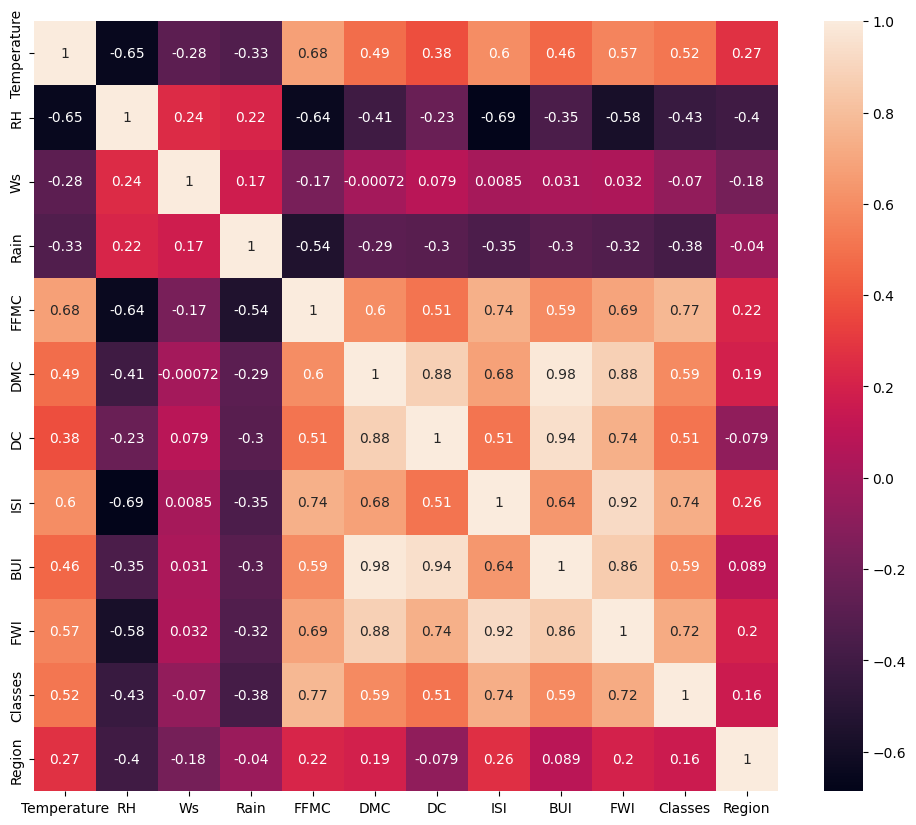

In [63]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True)

In [64]:
# def correlation(df,threshold):
#   col_corr=set()
#   corr_matrix=df.corr()
#   for i in range(len(corr_matrix.columns)):
#     for j in range(i):
#       if abs(corr_matrix.iloc[i,j]) > threshold:
#         colname = corr_matrix.columns[i]
#         col_corr.add(colname)
#   return col_corr

In [65]:
## threshold--Domain expertise
# corr_features=correlation(x_train,0.85)
# print(corr_features)

In [66]:
##drop features when corrleation is more than 0.85
# x=x_train.drop(corr_features,axis=1,inplace=True,errors='ignore')
# y=x_test.drop(corr_features,axis=1,inplace=True,errors='ignore')
# x_train.shape,x_test.shape


In [67]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [68]:
x_train_scaler,x_test_scaler

(array([[-0.87563202,  0.21321832,  1.28577038, ..., -0.76790976,
         -1.14434427, -1.01036297],
        [ 0.22209084, -1.65484925,  0.14504117, ...,  3.10086694,
          0.8738629 ,  0.98974332],
        [ 1.5942444 , -1.25454906, -0.99568804, ..., -0.24276653,
          0.8738629 ,  0.98974332],
        ...,
        [-1.97335488,  0.947102  ,  0.52528424, ..., -1.03380506,
         -1.14434427, -1.01036297],
        [ 0.49652155, -0.18708188,  0.14504117, ...,  0.14278167,
          0.8738629 ,  0.98974332],
        [-0.60120131,  1.0138187 ,  2.04625653, ..., -0.99392076,
         -1.14434427, -1.01036297]]),
 array([[-0.32677059,  0.14650162, -0.2352019 , -0.38015572,  0.61070375,
         -0.07699537,  0.25303529,  0.17532762,  0.06301308,  0.8738629 ,
         -1.01036297],
        [ 0.22209084, -0.52066537, -0.99568804, -0.38015572,  0.71720269,
         -0.40637763, -0.41556406,  0.33729694, -0.42889324,  0.8738629 ,
         -1.01036297],
        [-1.15006273, -0.253798

Text(0.5, 1.0, 'x_train after scaling')

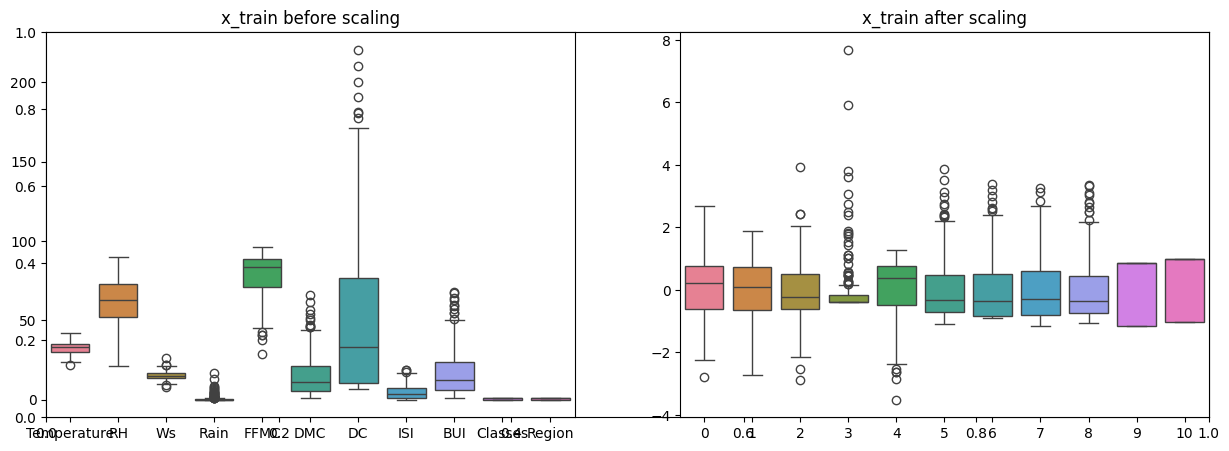

In [69]:
##box plot to understand te effect of standard scaler
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('x_train before scaling')
plt.subplot(1,2,2,)
sns.boxplot(data=x_train_scaler)
plt.title('x_train after scaling')

In [70]:
import numpy as np

print('Original x_train (first column) - Mean:', np.mean(x_train.iloc[:,0]))
print('Original x_train (first column) - Std Dev:', np.std(x_train.iloc[:,0]))
print('\nScaled x_train_scaler (first column) - Mean:', np.mean(x_train_scaler[:,0]))
print('Scaled x_train_scaler (first column) - Std Dev:', np.std(x_train_scaler[:,0]))

Original x_train (first column) - Mean: 32.19072164948454
Original x_train (first column) - Std Dev: 3.6439070023957294

Scaled x_train_scaler (first column) - Mean: -3.021637922691148e-16
Scaled x_train_scaler (first column) - Std Dev: 0.9999999999999998


Linear regression


mean absolute error 0.4267520614689853
mean squared error 0.33231115384863824
r2_score 0.9890356825759857


Text(0, 0.5, 'y_pred')

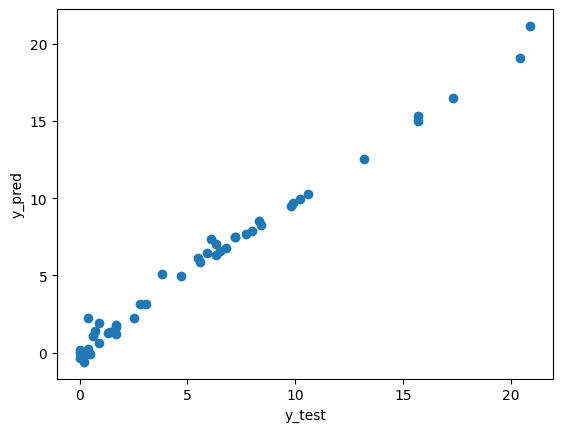

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
linear=LinearRegression()
linear.fit(x_train_scaler,y_train)
y_pred=linear.predict(x_test_scaler)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)
print('mean absolute error',mea)
print('mean squared error',mse)
print('r2_score',r2_score)
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

Lassocv


mean absolute error 0.4207314208345752
mean squared error 0.35615975662447386
r2_score 0.9882488186747138


Text(0, 0.5, 'y_pred')

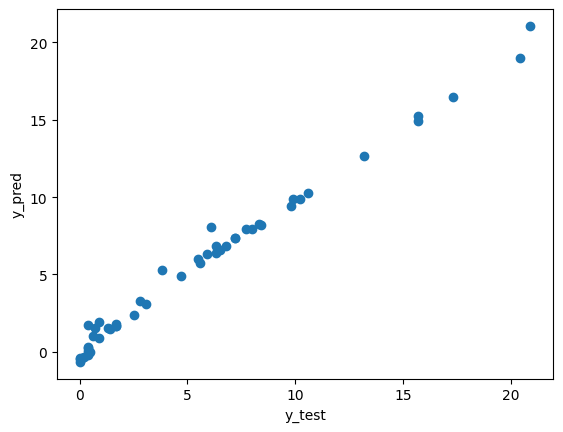

In [72]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
lassocv=LassoCV(cv=5)
lassocv.fit(x_train_scaler,y_train)
y_pred=lassocv.predict(x_test_scaler)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)
print('mean absolute error',mea)
print('mean squared error',mse)
print('r2_score',r2_score)
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

In [73]:
lassocv.alpha_

np.float64(0.033216911748928005)

In [74]:
lassocv.alphas_

array([7.1563667 , 6.67405153, 6.2242428 , 5.80474966, 5.41352896,
       5.04867523, 4.70841142, 4.39108025, 4.09513613, 3.81913766,
       3.56174057, 3.32169117, 3.09782031, 2.88903759, 2.69432612,
       2.51273756, 2.34338746, 2.18545099, 2.0381589 , 1.90079382,
       1.77268667, 1.65321353, 1.54179247, 1.43788081, 1.34097246,
       1.2505954 , 1.16630946, 1.08770411, 1.01439649, 0.94602956,
       0.88227033, 0.82280827, 0.76735374, 0.71563667, 0.66740515,
       0.62242428, 0.58047497, 0.5413529 , 0.50486752, 0.47084114,
       0.43910802, 0.40951361, 0.38191377, 0.35617406, 0.33216912,
       0.30978203, 0.28890376, 0.26943261, 0.25127376, 0.23433875,
       0.2185451 , 0.20381589, 0.19007938, 0.17726867, 0.16532135,
       0.15417925, 0.14378808, 0.13409725, 0.12505954, 0.11663095,
       0.10877041, 0.10143965, 0.09460296, 0.08822703, 0.08228083,
       0.07673537, 0.07156367, 0.06674052, 0.06224243, 0.0580475 ,
       0.05413529, 0.05048675, 0.04708411, 0.0439108 , 0.04095

In [75]:
lassocv.mse_path_

array([[68.58934997, 64.28650232, 49.25415197, 79.11474083, 38.68688171],
       [63.2664675 , 58.77362304, 43.20292636, 77.07183352, 34.66910628],
       [56.87389457, 51.79652473, 37.15764773, 69.4806422 , 31.16497557],
       [51.2737596 , 45.69461734, 31.98560721, 62.80993539, 27.46286399],
       [45.36816855, 40.35928545, 27.56726322, 56.94442062, 23.75447628],
       [39.875005  , 35.69250404, 23.79907917, 50.31847875, 20.54655878],
       [35.0794232 , 31.60885664, 20.59132915, 44.35263414, 17.77349727],
       [30.89154006, 28.0342798 , 17.86626498, 39.14265375, 15.37720198],
       [27.23334321, 24.90389594, 15.55674604, 34.59116894, 13.30754905],
       [24.03652419, 22.16129069, 13.60451947, 30.61376519, 11.52101422],
       [21.24273995, 19.75730052, 11.95924131, 27.13693185,  9.97950732],
       [18.80004176, 17.64896267, 10.57738151, 24.09623192,  8.65087048],
       [16.66356323, 15.79916526,  9.42117661, 21.43679316,  7.50627555],
       [14.79422393, 14.17520895,  8.4

Lasso Regression

mean absolute error 0.9552746314709515
mean squared error 1.4308089977464673
r2_score 0.9527917018651335


Text(0, 0.5, 'y_pred')

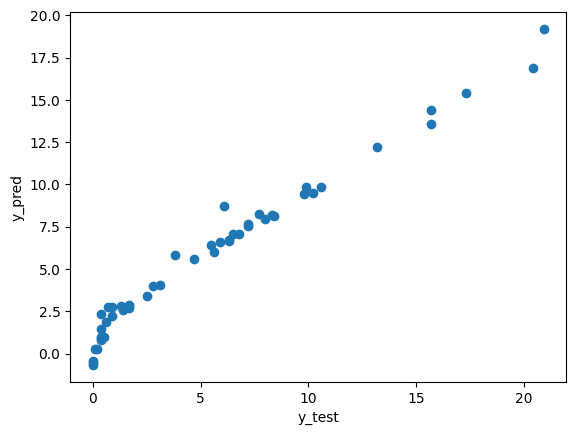

In [76]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
lasso=Lasso()
lasso.fit(x_train_scaler,y_train)
y_pred=lasso.predict(x_test_scaler)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)
print('mean absolute error',mea)
print('mean squared error',mse)
print('r2_score',r2_score)
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

Ridge Regression model


mean absolute error 0.46348598120275497
mean squared error 0.4694114296442019
r2_score 0.9845121782477887


Text(0, 0.5, 'y_pred')

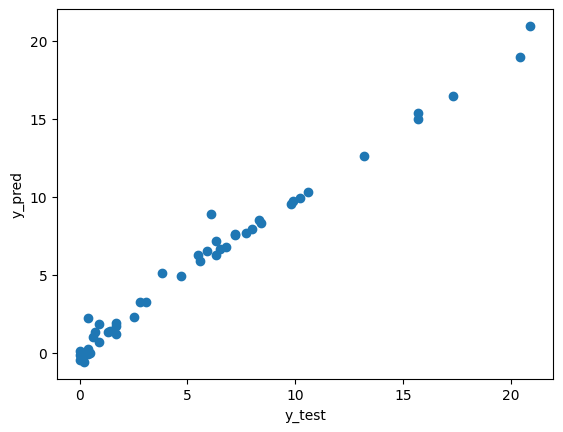

In [77]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
ridge=Ridge()
ridge.fit(x_train_scaler,y_train)
y_pred=ridge.predict(x_test_scaler)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)
print('mean absolute error',mea)
print('mean squared error',mse)
print('r2_score',r2_score)
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

Ridge CV


mean absolute error 0.639514606918707
mean squared error 0.7977669213987616
r2_score 0.973678374453303


Text(0, 0.5, 'y_pred')

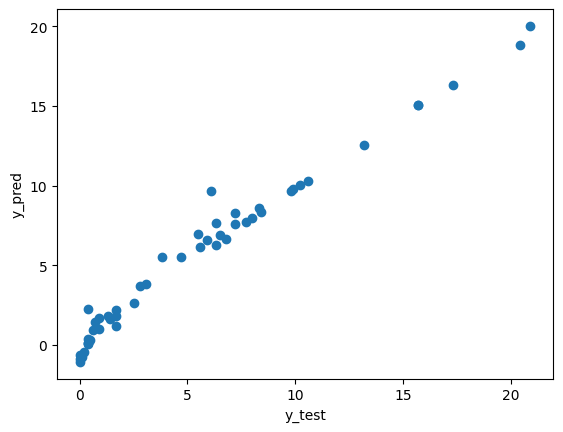

In [78]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
ridgecv=RidgeCV(cv=5)
ridgecv.fit(x_train_scaler,y_train)
y_pred=ridgecv.predict(x_test_scaler)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)
print('mean absolute error',mea)
print('mean squared error',mse)
print('r2_score',r2_score)
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

In [79]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

Elastic regression

mean absolute error 1.5279150847018705
mean squared error 3.5487893062683153
r2_score 0.8829107841423941


Text(0, 0.5, 'y_pred')

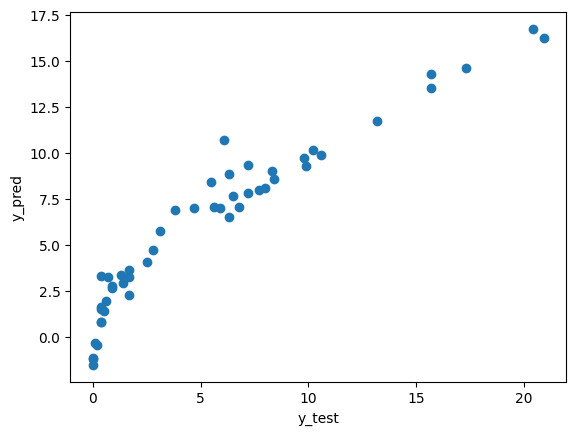

In [80]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
elasticnet=ElasticNet()
elasticnet.fit(x_train_scaler,y_train)
y_pred=elasticnet.predict(x_test_scaler)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)
print('mean absolute error',mea)
print('mean squared error',mse)
print('r2_score',r2_score)
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

Elasticnetcv


mean absolute error 0.49674555626350636
mean squared error 0.528171405134742
r2_score 0.982573443975273


Text(0, 0.5, 'y_pred')

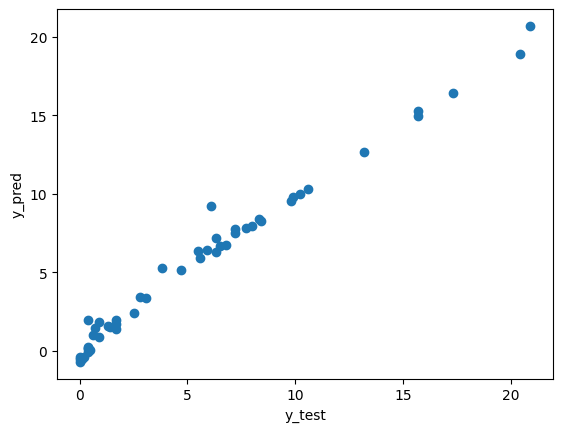

In [81]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
elasticnetcv=ElasticNetCV(cv=5)
elasticnetcv.fit(x_train_scaler,y_train)
y_pred=elasticnetcv.predict(x_test_scaler)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)
print('mean absolute error',mea)
print('mean squared error',mse)
print('r2_score',r2_score)
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

In [82]:
elasticnetcv.get_params()

{'alphas': None,
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 1000,
 'n_alphas': 100,
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': 0}

In [83]:
elasticnet.alpha

1.0

In [84]:
elasticnetcv.alphas_


array([14.31273339, 13.34810307, 12.44848559, 11.60949933, 10.82705793,
       10.09735046,  9.41682284,  8.78216049,  8.19027227,  7.63827533,
        7.12348114,  6.64338235,  6.19564061,  5.77807517,  5.38865224,
        5.02547512,  4.68677492,  4.37090197,  4.07631781,  3.80158763,
        3.54537335,  3.30642705,  3.08358493,  2.87576163,  2.68194492,
        2.50119081,  2.33261892,  2.17540821,  2.02879298,  1.89205912,
        1.76454067,  1.64561653,  1.53470749,  1.43127334,  1.33481031,
        1.24484856,  1.16094993,  1.08270579,  1.00973505,  0.94168228,
        0.87821605,  0.81902723,  0.76382753,  0.71234811,  0.66433823,
        0.61956406,  0.57780752,  0.53886522,  0.50254751,  0.46867749,
        0.4370902 ,  0.40763178,  0.38015876,  0.35453733,  0.33064271,
        0.30835849,  0.28757616,  0.26819449,  0.25011908,  0.23326189,
        0.21754082,  0.2028793 ,  0.18920591,  0.17645407,  0.16456165,
        0.15347075,  0.14312733,  0.13348103,  0.12448486,  0.11

In [85]:
import pickle

In [86]:
scaler


StandardScaler()

In [87]:
ridge

Ridge()

In [88]:
elasticnet

ElasticNet()

In [89]:
#model=elasticnet,elasticnetcv,ridge,lasso,lassocv,linear,ridgecv

In [91]:
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))